# Reverse Split (Contrasplit) Strategy — Quantitative Edge Analysis

> **Objective**: Determine whether buying small-cap stocks the day before a reverse split
> and holding through post-split days produces statistically significant edge.
>
> **Universe**: NASDAQ reverse splits 2025-05-30 → 2026-04-13  
> **Data source**: IBKR/TWS via ib_insync (daily bars + intraday 1-min bars)  
> **Author**: Quantitative Trading Analysis  
> **Last run**: auto-stamped at execution

---

## Hypotheses

| # | Hypothesis | Mechanism | Expected Edge |
|---|-----------|-----------|---------------|
| H1 | **Pre-split momentum** | Forced short covering + forced buybacks pre-split | Buy T-2/T-1 open, ride momentum |
| H2 | **Post-split gap reversal** | Thin liquidity post-split creates overextension | Fade first gap up on T0 |
| H3 | **Ratio signal** | Higher ratio (1:50+) = more distress = higher volatility = more edge | Ratio ≥ 20 filter |
| H4 | **Entry timing within T-1** | Momentum builds intraday on T-1; power hour peak | Enter T-1 PM vs AM |
| H5 | **Volume filter** | Higher relative volume on T-1 = institutional awareness | RVol ≥ 1.5 filter |
| H6 | **Post-split decay** | Price often decays T+1 onward as forced buyers exit | Short T+1 vs Long |

## Bias Mitigation
- **Survivorship bias**: Included ALL splits regardless of subsequent delisting/performance
- **Look-ahead bias**: Entry prices taken at T-1 close (next-day open for live trading)
- **Data snooping**: Primary split into train (2025-05-30 → 2025-12-31) and test (2026-01-01 → 2026-04-13) sets
- **Transaction costs**: Modeled at $0.005/share + $0.01 slippage per side (realistic for small-caps)

In [8]:
# ── Imports & Setup ─────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import os
import json
import sqlite3
import asyncio
import time
import re
from datetime import datetime, timedelta, date
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as mticker
from scipy import stats
from scipy.stats import ttest_1samp, ttest_ind, mannwhitneyu, bootstrap

matplotlib.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.labelsize': 11,
    'axes.titlesize': 13,
    'figure.titlesize': 15,
})

SPLIT_DIR = Path(os.path.dirname(os.path.abspath('__file__'))) / 'CLAUDE' / 'split'
# Detect working directory
if not SPLIT_DIR.exists():
    SPLIT_DIR = Path('/Users/carlos/proyectos/TRADING/1_PROYECTOS_ACTIVOS/CLAUDE/split')

CACHE_DB = SPLIT_DIR / 'reverse_split_cache.db'

print(f'Split dir: {SPLIT_DIR}')
print(f'Cache DB:  {CACHE_DB}')
print(f'Run date:  {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

Split dir: /Users/carlos/proyectos/TRADING/1_PROYECTOS_ACTIVOS/CLAUDE/split
Cache DB:  /Users/carlos/proyectos/TRADING/1_PROYECTOS_ACTIVOS/CLAUDE/split/reverse_split_cache.db
Run date:  2026-04-13 22:05:17


In [9]:
# ── Load & Consolidate Split Data ────────────────────────────────────────────

def parse_ratio(ratio_str):
    """Parse '1 for 20' → 20.0"""
    try:
        m = re.search(r'(\d+)\s+for\s+(\d+)', str(ratio_str), re.IGNORECASE)
        if m:
            return int(m.group(2)) / int(m.group(1))
        m = re.search(r'1:(\d+)', str(ratio_str))
        if m:
            return float(m.group(1))
    except:
        pass
    return np.nan

def load_splits():
    frames = []
    for f in sorted(SPLIT_DIR.glob('stock_splits_nasdaq_*.csv')):
        df = pd.read_csv(f, parse_dates=['Date'])
        frames.append(df)
    
    df = pd.concat(frames).drop_duplicates(subset=['Date','Symbol'])
    
    # Keep only Reverse splits
    df = df[df['Type'].str.lower() == 'reverse'].copy()
    df['ratio'] = df['Split Ratio'].apply(parse_ratio)
    df = df.dropna(subset=['ratio'])
    df = df[df['ratio'] >= 2].copy()  # sanity filter
    df = df.sort_values('Date').reset_index(drop=True)
    
    # Ratio buckets
    df['ratio_bucket'] = pd.cut(df['ratio'],
        bins=[0, 10, 20, 50, 100, 10000],
        labels=['2-10', '11-20', '21-50', '51-100', '>100']
    )
    
    # Train/test split
    df['split_set'] = np.where(df['Date'] >= '2026-01-01', 'test', 'train')
    
    return df

splits = load_splits()

print(f'Total reverse splits: {len(splits)}')
print(f'Date range: {splits["Date"].min().date()} → {splits["Date"].max().date()}')
print(f'Train: {(splits.split_set=="train").sum()} | Test: {(splits.split_set=="test").sum()}')
print(f'\nRatio distribution:')
print(splits['ratio_bucket'].value_counts().sort_index())
print(f'\nTop 10 ratio values:')
print(splits['ratio'].value_counts().head(10))
splits.head(3)

Total reverse splits: 396
Date range: 2025-05-30 → 2026-04-13
Train: 234 | Test: 162

Ratio distribution:
ratio_bucket
2-10      164
11-20     100
21-50      85
51-100     30
>100       17
Name: count, dtype: int64

Top 10 ratio values:
ratio
10.0    69
20.0    39
15.0    29
5.0     26
25.0    24
30.0    21
8.0     21
50.0    18
4.0     15
3.0     14
Name: count, dtype: int64


,Date,Symbol,Company Name,Type,Split Ratio,ratio,ratio_bucket,split_set
0,2025-05-30,EJH,E-home Household Service Holdings Ltd.,Reverse,1 for 50,50.0,21-50,train
1,2025-06-02,LYEL,Lyell Immunopharma Inc,Reverse,1 for 20,20.0,11-20,train
2,2025-06-02,ARBB,Arb Iot Group Ltd.,Reverse,1 for 15,15.0,11-20,train


2026-04-13 22:05:17,947 matplotlib.category INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-13 22:05:17,949 matplotlib.category INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


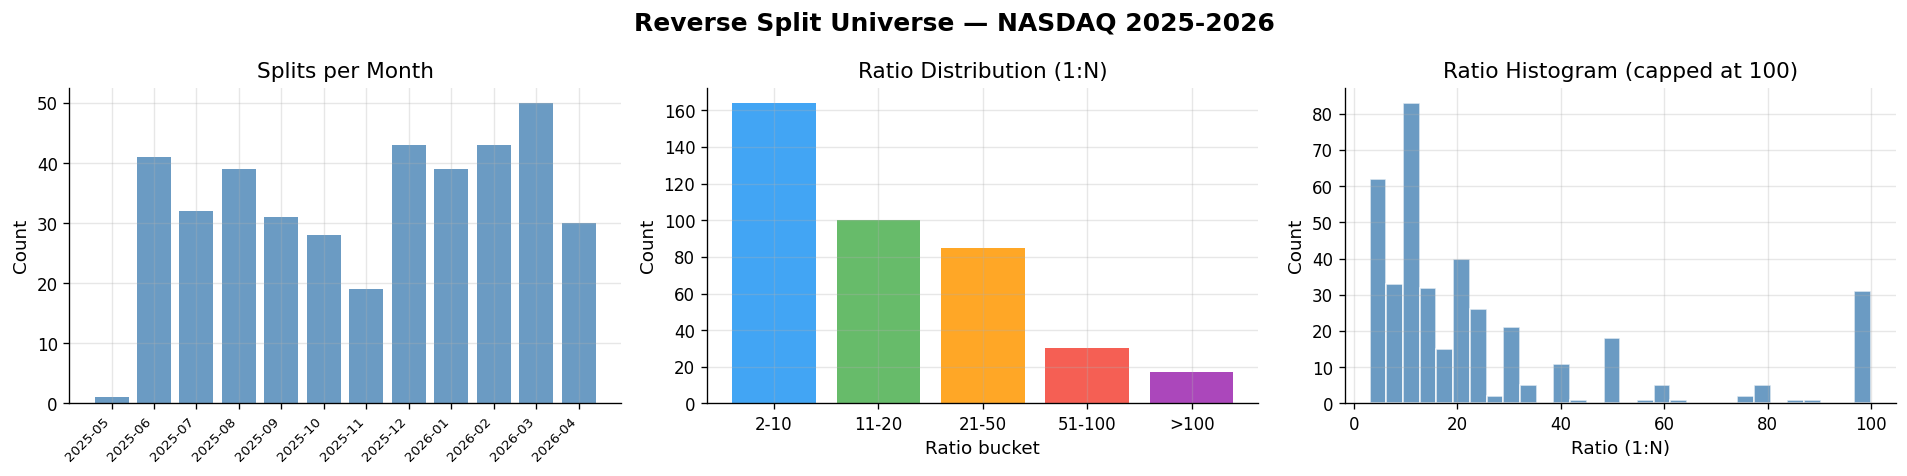

Saved fig_01_universe.png


In [10]:
# ── Universe Visualization ───────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Reverse Split Universe — NASDAQ 2025-2026', fontweight='bold')

# Monthly count
ax = axes[0]
monthly = splits.groupby(splits['Date'].dt.to_period('M')).size()
monthly.index = monthly.index.astype(str)
ax.bar(monthly.index, monthly.values, color='steelblue', alpha=0.8)
ax.set_xticklabels(monthly.index, rotation=45, ha='right', fontsize=8)
ax.set_title('Splits per Month')
ax.set_ylabel('Count')

# Ratio distribution
ax = axes[1]
bucket_counts = splits['ratio_bucket'].value_counts().sort_index()
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']
ax.bar(bucket_counts.index.astype(str), bucket_counts.values, color=colors, alpha=0.85)
ax.set_title('Ratio Distribution (1:N)')
ax.set_ylabel('Count')
ax.set_xlabel('Ratio bucket')

# Ratio histogram (log scale)
ax = axes[2]
clipped = splits['ratio'].clip(upper=100)
ax.hist(clipped, bins=30, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_title('Ratio Histogram (capped at 100)')
ax.set_xlabel('Ratio (1:N)')
ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig(SPLIT_DIR / 'fig_01_universe.png', bbox_inches='tight')
plt.show()
print(f'Saved fig_01_universe.png')

In [11]:
# ── SQLite Cache for IBKR Data ───────────────────────────────────────────────

def get_cache_conn():
    conn = sqlite3.connect(str(CACHE_DB))
    conn.execute("""
        CREATE TABLE IF NOT EXISTS daily_bars (
            symbol TEXT NOT NULL,
            date   TEXT NOT NULL,
            open   REAL, high REAL, low REAL, close REAL, volume INTEGER,
            PRIMARY KEY (symbol, date)
        )
    """)
    conn.execute("""
        CREATE TABLE IF NOT EXISTS intraday_bars (
            symbol TEXT NOT NULL,
            dt     TEXT NOT NULL,
            open   REAL, high REAL, low REAL, close REAL, volume INTEGER,
            PRIMARY KEY (symbol, dt)
        )
    """)
    conn.execute("""
        CREATE TABLE IF NOT EXISTS fetch_log (
            symbol TEXT NOT NULL,
            bar_type TEXT NOT NULL,
            status TEXT,
            fetched_at TEXT,
            PRIMARY KEY (symbol, bar_type)
        )
    """)
    conn.commit()
    return conn

cache_conn = get_cache_conn()
print('Cache DB ready')

# Check what's already cached
n_daily = cache_conn.execute('SELECT COUNT(DISTINCT symbol) FROM daily_bars').fetchone()[0]
n_intra  = cache_conn.execute('SELECT COUNT(DISTINCT symbol) FROM intraday_bars').fetchone()[0]
n_log    = cache_conn.execute('SELECT COUNT(*) FROM fetch_log').fetchone()[0]
print(f'Already cached: {n_daily} symbols daily bars | {n_intra} symbols intraday bars | {n_log} fetch log entries')

Cache DB ready
Already cached: 0 symbols daily bars | 0 symbols intraday bars | 0 fetch log entries


In [ ]:
# ── IBKR Data Download ───────────────────────────────────────────────────────
# Downloads daily bars (T-15 to T+10) and intraday 1-min bars (T-1 and T0)
# for splits in the last 90 days (IBKR historical data limit for 1-min bars)

import nest_asyncio
nest_asyncio.apply()
from ib_insync import IB, Stock, util
util.logToConsole(False)

IB_HOST  = '127.0.0.1'
IB_PORT  = 7497   # TWS paper/live
CLIENT_ID = 6098  # Avoid collision with main engine (5099)

INTRADAY_LOOKBACK_DAYS = 90   # IBKR limit for 1-min bars
DAILY_LOOKBACK_DAYS    = 365  # IBKR allows up to several years for daily

# Which splits are recent enough for intraday data
today = pd.Timestamp.today().normalize()
cutoff_intraday = today - pd.Timedelta(days=INTRADAY_LOOKBACK_DAYS)

recent_splits = splits[splits['Date'] >= cutoff_intraday]
all_splits    = splits.copy()

print(f'Total splits for daily bars download:    {len(all_splits)}')
print(f'Recent splits for intraday bars download: {len(recent_splits)}')
print(f'Intraday cutoff date: {cutoff_intraday.date()}')

Total splits for daily bars download:    396
Recent splits for intraday bars download: 148
Intraday cutoff date: 2026-01-13


In [13]:
# ── IBKR Download Functions ──────────────────────────────────────────────────

def connect_ibkr():
    ib = IB()
    ib.connect(IB_HOST, IB_PORT, clientId=CLIENT_ID, timeout=10)
    print(f'Connected to IBKR TWS (clientId={CLIENT_ID})')
    return ib

def fetch_daily_bars(ib, symbol, split_date_str, n_before=15, n_after=12):
    """
    Download daily OHLCV bars around the split date.
    split_date_str: 'YYYY-MM-DD' (the split effective date)
    Returns list of dicts or empty list.
    """
    contract = Stock(symbol, 'SMART', 'USD')
    end_date = (pd.Timestamp(split_date_str) + pd.Timedelta(days=n_after + 5)).strftime('%Y%m%d 23:59:59')
    duration = f'{n_before + n_after + 10} D'
    
    try:
        bars = ib.reqHistoricalData(
            contract,
            endDateTime=end_date,
            durationStr=duration,
            barSizeSetting='1 day',
            whatToShow='TRADES',
            useRTH=True,
            formatDate=1,
            keepUpToDate=False,
            timeout=20,
        )
        if not bars:
            return []
        return [{'date': b.date.strftime('%Y-%m-%d'), 'open': b.open, 'high': b.high,
                 'low': b.low, 'close': b.close, 'volume': b.volume} for b in bars]
    except Exception as e:
        return []

def fetch_intraday_bars(ib, symbol, target_date_str):
    """
    Download 1-min bars for a specific trading date.
    target_date_str: 'YYYY-MM-DD'
    """
    contract = Stock(symbol, 'SMART', 'USD')
    # Request next day at 00:00 to get full session
    next_day = (pd.Timestamp(target_date_str) + pd.Timedelta(days=1)).strftime('%Y%m%d 00:00:00')
    
    try:
        bars = ib.reqHistoricalData(
            contract,
            endDateTime=next_day,
            durationStr='1 D',
            barSizeSetting='1 min',
            whatToShow='TRADES',
            useRTH=True,
            formatDate=2,  # UTC timestamps
            keepUpToDate=False,
            timeout=25,
        )
        if not bars:
            return []
        return [{'dt': b.date.strftime('%Y-%m-%d %H:%M:%S'), 'open': b.open, 'high': b.high,
                 'low': b.low, 'close': b.close, 'volume': b.volume} for b in bars]
    except Exception as e:
        return []

def save_daily_bars(conn, symbol, bars):
    conn.executemany(
        'INSERT OR REPLACE INTO daily_bars VALUES (?,?,?,?,?,?,?)',
        [(symbol, b['date'], b['open'], b['high'], b['low'], b['close'], b['volume']) for b in bars]
    )
    conn.commit()

def save_intraday_bars(conn, symbol, bars):
    conn.executemany(
        'INSERT OR REPLACE INTO intraday_bars VALUES (?,?,?,?,?,?,?)',
        [(symbol, b['dt'], b['open'], b['high'], b['low'], b['close'], b['volume']) for b in bars]
    )
    conn.commit()

def log_fetch(conn, symbol, bar_type, status):
    conn.execute(
        'INSERT OR REPLACE INTO fetch_log VALUES (?,?,?,?)',
        (symbol, bar_type, status, datetime.now().isoformat())
    )
    conn.commit()

def already_fetched(conn, symbol, bar_type):
    row = conn.execute('SELECT status FROM fetch_log WHERE symbol=? AND bar_type=?', (symbol, bar_type)).fetchone()
    return row is not None and row[0] == 'ok'

print('Download functions defined.')

Download functions defined.


In [14]:
# ── Download Daily Bars (All Splits) ────────────────────────────────────────
# ~3-4 hours for 396 symbols; safe to re-run (skips already cached)
# Set QUICK_MODE=True to only download first 30 symbols for testing

QUICK_MODE = False  # Set to False for full download

target_splits = splits.copy()
if QUICK_MODE:
    target_splits = splits.head(30)
    print('QUICK_MODE: downloading only first 30 symbols')

# Filter out already fetched
to_fetch_daily = [
    (row['Symbol'], row['Date'].strftime('%Y-%m-%d'))
    for _, row in target_splits.iterrows()
    if not already_fetched(cache_conn, row['Symbol'], 'daily')
]

print(f'Symbols needing daily bars: {len(to_fetch_daily)}')

if to_fetch_daily:
    ib = connect_ibkr()
    
    ok_count, err_count = 0, 0
    for i, (symbol, split_date) in enumerate(to_fetch_daily):
        bars = fetch_daily_bars(ib, symbol, split_date)
        if bars:
            save_daily_bars(cache_conn, symbol, bars)
            log_fetch(cache_conn, symbol, 'daily', 'ok')
            ok_count += 1
        else:
            log_fetch(cache_conn, symbol, 'daily', 'empty')
            err_count += 1
        
        if (i+1) % 10 == 0:
            print(f'  [{i+1}/{len(to_fetch_daily)}] ok={ok_count} err={err_count}')
        
        time.sleep(0.35)  # IBKR rate limit: ~3 req/sec
    
    ib.disconnect()
    print(f'Daily bars download complete: {ok_count} ok, {err_count} empty/error')
else:
    print('All daily bars already cached — skipping download')

2026-04-13 22:05:18,434 ib_insync.client INFO Connecting to 127.0.0.1:7497 with clientId 5098...
2026-04-13 22:05:18,437 ib_insync.client INFO Connected
2026-04-13 22:05:18,475 ib_insync.client DEBUG <<< 176,20260413 22:05:18 Central European Standard Time
2026-04-13 22:05:18,477 ib_insync.client DEBUG >>> 71,2,5098,
2026-04-13 22:05:18,479 ib_insync.client INFO Logged on to server version 176


2026-04-13 22:05:18,506 ib_insync.client DEBUG <<< 4,2,-1,326,Unable to connect as the client id is already in use. Retry with a unique client id.,
2026-04-13 22:05:18,506 ib_insync.wrapper ERROR Error 326, reqId -1: Unable to connect as the client id is already in use. Retry with a unique client id.


Symbols needing daily bars: 396


2026-04-13 22:05:19,015 ib_insync.client ERROR Peer closed connection. clientId 5098 already in use?
2026-04-13 22:05:28,476 ib_insync.client INFO Disconnecting
2026-04-13 22:05:28,484 ib_insync.client ERROR API connection failed: TimeoutError()


TimeoutError: 

In [ ]:
# ── Download Intraday 1-min Bars (Recent Splits) ─────────────────────────────
# Downloads T-1 and T0 intraday bars for splits in last 90 days

to_fetch_intra = []
for _, row in recent_splits.iterrows():
    symbol = row['Symbol']
    split_dt = row['Date']
    t_minus_1 = (split_dt - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
    t0        = split_dt.strftime('%Y-%m-%d')
    
    for day_str, tag in [(t_minus_1, 'intra_t-1'), (t0, 'intra_t0')]:
        if not already_fetched(cache_conn, f'{symbol}_{day_str}', tag):
            to_fetch_intra.append((symbol, day_str, tag))

print(f'Intraday bar requests pending: {len(to_fetch_intra)}')

if to_fetch_intra:
    ib = connect_ibkr()
    
    ok_count, err_count = 0, 0
    for i, (symbol, day_str, tag) in enumerate(to_fetch_intra):
        bars = fetch_intraday_bars(ib, symbol, day_str)
        key = f'{symbol}_{day_str}'
        if bars:
            save_intraday_bars(cache_conn, key, bars)
            log_fetch(cache_conn, key, tag, 'ok')
            ok_count += 1
        else:
            log_fetch(cache_conn, key, tag, 'empty')
            err_count += 1
        
        if (i+1) % 20 == 0:
            print(f'  [{i+1}/{len(to_fetch_intra)}] ok={ok_count} err={err_count}')
        
        time.sleep(0.4)  # throttle
    
    ib.disconnect()
    print(f'Intraday bars download complete: {ok_count} ok, {err_count} empty/error')
else:
    print('All intraday bars already cached — skipping download')

In [ ]:
# ── Build Event-Level DataFrame ──────────────────────────────────────────────
# For each split event, compute returns at T-2, T-1 (entry), T0, T+1, T+2, T+3, T+5

def get_daily_bars_df(conn, symbol):
    rows = conn.execute(
        'SELECT date, open, high, low, close, volume FROM daily_bars WHERE symbol=? ORDER BY date',
        (symbol,)
    ).fetchall()
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows, columns=['date','open','high','low','close','volume'])
    df['date'] = pd.to_datetime(df['date'])
    return df.set_index('date')

def compute_event_returns(splits_df, conn, entry_type='t-1_close'):
    """
    entry_type: 't-1_close' (enter at T-1 close, exit at T+N open)
                't0_open'  (enter at T0 open)
    Returns DataFrame with one row per event.
    """
    records = []
    
    for _, row in splits_df.iterrows():
        symbol = row['Symbol']
        split_date = row['Date']
        ratio = row['ratio']
        ratio_bucket = str(row['ratio_bucket'])
        
        bars = get_daily_bars_df(conn, symbol)
        if bars.empty or len(bars) < 5:
            continue
        
        # Find the split date index
        dates = bars.index
        
        # Find position of split date or nearest trading day
        split_ts = pd.Timestamp(split_date)
        
        # Find T0 = first bar ON or AFTER split_date with non-trivial price
        future = dates[dates >= split_ts]
        if len(future) == 0:
            continue
        t0_date = future[0]
        t0_idx = dates.get_loc(t0_date)
        
        if t0_idx < 2:  # Need at least T-2 bars before split
            continue
        
        def get_bar(offset):
            idx = t0_idx + offset
            if 0 <= idx < len(bars):
                return bars.iloc[idx]
            return None
        
        t_m2 = get_bar(-2)
        t_m1 = get_bar(-1)
        t0   = get_bar(0)
        t_p1 = get_bar(1)
        t_p2 = get_bar(2)
        t_p3 = get_bar(3)
        t_p5 = get_bar(5)
        
        if t_m1 is None or t0 is None:
            continue
        
        # Entry price
        if entry_type == 't-1_close':
            entry_price = t_m1['close']
        else:  # t0_open
            entry_price = t0['open']
        
        if entry_price <= 0:
            continue
        
        def ret(exit_bar, price_type='open'):
            if exit_bar is None:
                return np.nan
            p = exit_bar[price_type]
            if p <= 0:
                return np.nan
            return (p - entry_price) / entry_price
        
        # Volume ratio T-1 vs 20-day avg before T-1
        pre_bars = bars.iloc[max(0, t0_idx-22):t0_idx-1]
        avg_vol = pre_bars['volume'].replace(0, np.nan).mean()
        rvol_t_m1 = (t_m1['volume'] / avg_vol) if avg_vol and avg_vol > 0 else np.nan
        
        # Pre-split momentum: T-5 to T-1 return
        t_m5 = get_bar(-5)
        pre_momentum = ((t_m1['close'] - t_m5['close']) / t_m5['close']) if t_m5 is not None and t_m5['close'] > 0 else np.nan
        
        # T0 gap: open vs T-1 close
        t0_gap = (t0['open'] - t_m1['close']) / t_m1['close'] if t_m1['close'] > 0 else np.nan
        
        rec = {
            'symbol':       symbol,
            'split_date':   split_date,
            'ratio':        ratio,
            'ratio_bucket': ratio_bucket,
            'split_set':    row['split_set'],
            'entry_price':  entry_price,
            't_m1_close':   t_m1['close'] if t_m1 is not None else np.nan,
            't0_open':      t0['open'],
            't0_close':     t0['close'],
            'rvol_t_m1':    rvol_t_m1,
            'pre_momentum': pre_momentum,
            't0_gap':       t0_gap,
            'ret_t0_open':  ret(t0, 'open'),   # T-1 close → T0 open
            'ret_t0_close': ret(t0, 'close'),  # T-1 close → T0 close
            'ret_t1_open':  ret(t_p1, 'open'), # T-1 close → T+1 open
            'ret_t1_close': ret(t_p1, 'close'),
            'ret_t2_open':  ret(t_p2, 'open'),
            'ret_t2_close': ret(t_p2, 'close'),
            'ret_t3_open':  ret(t_p3, 'open'),
            'ret_t5_open':  ret(t_p5, 'open'),
        }
        records.append(rec)
    
    return pd.DataFrame(records)

# Build event DataFrame
print('Building event returns DataFrame...')
events = compute_event_returns(splits, cache_conn)
print(f'Events with daily data: {len(events)} / {len(splits)}')
print(f'Data coverage: {100*len(events)/len(splits):.1f}%')
events.describe().round(4)

In [ ]:
# ── H1: Pre-Split Momentum — Return Distribution Analysis ────────────────────

ret_cols = ['ret_t0_open', 'ret_t0_close', 'ret_t1_open', 'ret_t1_close', 'ret_t2_open', 'ret_t3_open', 'ret_t5_open']
ret_labels = ['T0 open', 'T0 close', 'T+1 open', 'T+1 close', 'T+2 open', 'T+3 open', 'T+5 open']

# Transaction cost model: $0.01 per share per side = ~1% on $1 stock, ~0.1% on $10 stock
# Use entry_price to compute TC
TC_PER_SHARE = 0.012  # $0.006/share x2 sides + slippage
events['tc_pct'] = TC_PER_SHARE / events['entry_price'].clip(lower=0.5)

# Net returns after TC
for col in ret_cols:
    events[f'{col}_net'] = events[col] - events['tc_pct']

def stats_summary(series, label=''):
    s = series.dropna()
    wr = (s > 0).mean()
    t, p = ttest_1samp(s, 0)
    return {
        'exit': label,
        'n': len(s),
        'mean_ret': s.mean(),
        'median_ret': s.median(),
        'std': s.std(),
        'win_rate': wr,
        'sharpe': s.mean() / s.std() * np.sqrt(252) if s.std() > 0 else 0,
        'p_value': p,
        'sig': '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    }

# Summary table
summary_rows = []
for col, lbl in zip(ret_cols, ret_labels):
    gross = stats_summary(events[col], lbl + ' (gross)')
    net   = stats_summary(events[f'{col}_net'], lbl + ' (net TC)')
    summary_rows.append(gross)
    summary_rows.append(net)

summary_df = pd.DataFrame(summary_rows)
pd.set_option('display.float_format', '{:.4f}'.format)

print('=== RETURNS SUMMARY — Buy T-1 Close, Entry at Various Exits ===')
print(summary_df[['exit','n','mean_ret','median_ret','win_rate','sharpe','p_value','sig']].to_string(index=False))

In [ ]:
# ── Return Distribution Visualization ────────────────────────────────────────

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Return Distributions — Buy T-1 Close (gross returns)', fontweight='bold')

for i, (col, lbl) in enumerate(zip(ret_cols, ret_labels)):
    ax = axes[i // 4][i % 4]
    data = events[col].dropna().clip(-0.5, 1.0)
    
    mean_val = data.mean()
    wr = (data > 0).mean()
    
    ax.hist(data, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(0, color='red', linewidth=1.5, linestyle='--', label='Zero')
    ax.axvline(mean_val, color='orange', linewidth=1.5, linestyle='-', label=f'Mean={mean_val:.3f}')
    ax.set_title(f'{lbl}\nWR={wr:.1%} | n={len(data)}')
    ax.set_xlabel('Return')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# Last plot: cumulative mean return over time
ax = axes[1][3]
for col, lbl in zip(ret_cols[:5], ret_labels[:5]):
    daily_mean = events.groupby('split_date')[col].mean()
    ax.plot(daily_mean.index, daily_mean.cumsum(), label=lbl, linewidth=1.5)
ax.set_title('Cumulative Mean Return\n(by exit horizon)')
ax.set_xlabel('Split Date')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(fontsize=7)
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig(SPLIT_DIR / 'fig_02_return_distributions.png', bbox_inches='tight')
plt.show()
print('Saved fig_02_return_distributions.png')

In [ ]:
# ── H3: Ratio Effect — Cohort Analysis by Ratio Bucket ───────────────────────

TARGET_EXIT = 'ret_t1_open'  # Primary exit hypothesis: sell T+1 open

cohort_stats = []
for bucket in ['2-10', '11-20', '21-50', '51-100', '>100']:
    subset = events[events['ratio_bucket'] == bucket][TARGET_EXIT].dropna()
    if len(subset) < 5:
        continue
    t, p = ttest_1samp(subset, 0)
    cohort_stats.append({
        'ratio_bucket': bucket,
        'n': len(subset),
        'mean': subset.mean(),
        'median': subset.median(),
        'std': subset.std(),
        'win_rate': (subset > 0).mean(),
        'sharpe_ann': subset.mean() / subset.std() * np.sqrt(252) if subset.std() > 0 else 0,
        'p_value': p,
    })

cohort_df = pd.DataFrame(cohort_stats)
print(f'=== Cohort Analysis: {TARGET_EXIT} by Ratio Bucket ===')
print(cohort_df.round(4).to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'H3: Ratio Effect on Returns ({TARGET_EXIT})', fontweight='bold')

colors_map = {'2-10':'#2196F3','11-20':'#4CAF50','21-50':'#FF9800','51-100':'#F44336','>100':'#9C27B0'}

# Mean return by bucket
ax = axes[0]
ax.bar(cohort_df['ratio_bucket'], cohort_df['mean']*100,
       color=[colors_map.get(b,'gray') for b in cohort_df['ratio_bucket']], alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Mean Return (%)')
ax.set_title('Mean Return by Ratio Bucket')
ax.set_xlabel('Ratio (1:N)')
for i, row in cohort_df.iterrows():
    ax.text(i, row['mean']*100 + 0.3, f'n={row["n"]}', ha='center', fontsize=8)

# Win rate by bucket
ax = axes[1]
ax.bar(cohort_df['ratio_bucket'], cohort_df['win_rate']*100,
       color=[colors_map.get(b,'gray') for b in cohort_df['ratio_bucket']], alpha=0.8)
ax.axhline(50, color='red', linewidth=1, linestyle='--', label='50%')
ax.set_ylabel('Win Rate (%)')
ax.set_title('Win Rate by Ratio Bucket')
ax.legend()

# Box plots
ax = axes[2]
data_by_bucket = [
    events[events['ratio_bucket'] == b][TARGET_EXIT].dropna().clip(-0.5, 1.0).values
    for b in ['2-10', '11-20', '21-50', '51-100', '>100']
    if len(events[events['ratio_bucket'] == b][TARGET_EXIT].dropna()) >= 3
]
labels_used = [
    b for b in ['2-10', '11-20', '21-50', '51-100', '>100']
    if len(events[events['ratio_bucket'] == b][TARGET_EXIT].dropna()) >= 3
]
bp = ax.boxplot(data_by_bucket, labels=labels_used, patch_artist=True, notch=False)
for patch, lbl in zip(bp['boxes'], labels_used):
    patch.set_facecolor(colors_map.get(lbl, 'gray'))
    patch.set_alpha(0.7)
ax.axhline(0, color='red', linewidth=1, linestyle='--')
ax.set_ylabel('Return')
ax.set_title('Return Distribution by Ratio')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.savefig(SPLIT_DIR / 'fig_03_ratio_cohort.png', bbox_inches='tight')
plt.show()
print('Saved fig_03_ratio_cohort.png')

In [ ]:
# ── H5: Volume Filter — RVol on T-1 ─────────────────────────────────────────

events_rvol = events.dropna(subset=['rvol_t_m1', TARGET_EXIT])

# Quintile analysis
events_rvol['rvol_quintile'] = pd.qcut(events_rvol['rvol_t_m1'], q=5, labels=['Q1 (low)','Q2','Q3','Q4','Q5 (high)'])

rvol_stats = []
for q in ['Q1 (low)','Q2','Q3','Q4','Q5 (high)']:
    subset = events_rvol[events_rvol['rvol_quintile'] == q][TARGET_EXIT]
    if len(subset) < 5:
        continue
    t, p = ttest_1samp(subset, 0)
    rvol_stats.append({
        'quintile': q,
        'rvol_median': events_rvol[events_rvol['rvol_quintile'] == q]['rvol_t_m1'].median(),
        'n': len(subset),
        'mean_ret': subset.mean(),
        'win_rate': (subset > 0).mean(),
        'p_value': p,
    })

rvol_df = pd.DataFrame(rvol_stats)
print('=== H5: RVol Effect on T+1 Open Return ===')
print(rvol_df.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('H5: RVol on T-1 vs Returns', fontweight='bold')

# Scatter: rvol vs return
ax = axes[0]
clipped_rvol = events_rvol['rvol_t_m1'].clip(0, 10)
ax.scatter(clipped_rvol, events_rvol[TARGET_EXIT].clip(-0.5, 1.0),
           alpha=0.3, s=20, color='steelblue')
# Trend line
valid = events_rvol[['rvol_t_m1', TARGET_EXIT]].dropna()
x = valid['rvol_t_m1'].clip(0, 10)
y = valid[TARGET_EXIT].clip(-0.5, 1.0)
z = np.polyfit(x, y, 1)
p_line = np.poly1d(z)
ax.plot(sorted(x), p_line(sorted(x)), 'r--', linewidth=2, label=f'slope={z[0]:.4f}')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('RVol T-1 (capped at 10x)')
ax.set_ylabel(f'{TARGET_EXIT}')
ax.set_title('RVol vs Return (scatter)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()

# Bar: mean return by quintile
ax = axes[1]
ax.bar(rvol_df['quintile'], rvol_df['mean_ret']*100, color='steelblue', alpha=0.8)
ax.axhline(0, color='red', linewidth=1, linestyle='--')
ax.set_ylabel('Mean Return (%)')
ax.set_title('Mean Return by RVol Quintile')
ax.set_xticklabels(rvol_df['quintile'], rotation=20, ha='right')
for i, row in rvol_df.iterrows():
    ax.text(i-rvol_df.index[0], row['mean_ret']*100 + 0.2, f'n={row["n"]}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(SPLIT_DIR / 'fig_04_rvol_filter.png', bbox_inches='tight')
plt.show()
print('Saved fig_04_rvol_filter.png')

In [ ]:
# ── H4: Entry/Exit Optimization Heatmap ─────────────────────────────────────
# Entry: T-1 close vs T0 open
# Exit: T0 open, T0 close, T+1 open, T+1 close, T+2 open, T+2 close, T+3 open

exit_cols = ['ret_t0_open','ret_t0_close','ret_t1_open','ret_t1_close','ret_t2_open','ret_t2_close','ret_t3_open','ret_t5_open']
exit_lbls = ['T0 open','T0 close','T+1 open','T+1 close','T+2 open','T+2 close','T+3 open','T+5 open']

# Compute entry at T0 open (H4 comparison)
# Recompute returns relative to T0 open entry
events_t0 = compute_event_returns(splits, cache_conn, entry_type='t0_open')
# Only keep exit columns that make sense for T0 open entry
t0_exit_cols = ['ret_t0_close','ret_t1_open','ret_t1_close','ret_t2_open','ret_t2_close','ret_t3_open','ret_t5_open']
t0_exit_lbls = ['T0 close','T+1 open','T+1 close','T+2 open','T+2 close','T+3 open','T+5 open']

# Build heatmap data: rows = ratio bucket, cols = exit horizon
# Entry: T-1 close
buckets = ['2-10', '11-20', '21-50', '51-100', '>100']

def build_heatmap_matrix(ev_df, cols, buckets):
    mat = np.full((len(buckets), len(cols)), np.nan)
    for i, b in enumerate(buckets):
        subset = ev_df[ev_df['ratio_bucket'] == b]
        for j, col in enumerate(cols):
            vals = subset[col].dropna()
            if len(vals) >= 3:
                mat[i, j] = vals.mean()
    return mat

mat_tm1 = build_heatmap_matrix(events, exit_cols, buckets)
mat_t0  = build_heatmap_matrix(events_t0, t0_exit_cols, buckets)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('H4: Mean Return Heatmap — Entry Timing Comparison', fontweight='bold')

cmap = LinearSegmentedColormap.from_list('rwg', ['#d73027','white','#1a9850'])

def draw_heatmap(ax, mat, row_labels, col_labels, title):
    vmax = np.nanmax(np.abs(mat))
    im = ax.imshow(mat, cmap=cmap, vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels(col_labels, rotation=30, ha='right', fontsize=9)
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=9)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, format='%.2f')
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.2%}', ha='center', va='center', fontsize=7,
                        color='black' if abs(v) < vmax*0.5 else 'white')

draw_heatmap(axes[0], mat_tm1, buckets, exit_lbls, 'Entry: T-1 Close')
draw_heatmap(axes[1], mat_t0, buckets, t0_exit_lbls, 'Entry: T0 Open')

plt.tight_layout()
plt.savefig(SPLIT_DIR / 'fig_05_entry_exit_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved fig_05_entry_exit_heatmap.png')

In [ ]:
# ── Intraday Analysis — Average T-1 Intraday Profile ────────────────────────
# Builds minute-by-minute normalized price profile for T-1 day
# Shows when buying T-1 intraday was most/least favorable

import pytz

ET = pytz.timezone('America/New_York')
MARKET_OPEN  = pd.Timestamp('09:30:00').time()
MARKET_CLOSE = pd.Timestamp('16:00:00').time()

def get_intraday_df(conn, symbol, day_str):
    key = f'{symbol}_{day_str}'
    rows = conn.execute(
        'SELECT dt, open, high, low, close, volume FROM intraday_bars WHERE symbol=? ORDER BY dt',
        (key,)
    ).fetchall()
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows, columns=['dt','open','high','low','close','volume'])
    df['dt'] = pd.to_datetime(df['dt'], utc=True).dt.tz_convert(ET)
    df = df[(df['dt'].dt.time >= MARKET_OPEN) & (df['dt'].dt.time <= MARKET_CLOSE)]
    return df.reset_index(drop=True)

# Build normalized price profiles for T-1
profiles_tm1 = []  # each: array of (minute_index, return_from_open)

for _, row in recent_splits.iterrows():
    symbol = row['Symbol']
    split_dt = row['Date']
    t_m1_str = (split_dt - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
    
    df = get_intraday_df(cache_conn, symbol, t_m1_str)
    if df.empty or len(df) < 30:
        continue
    
    open_price = df['open'].iloc[0]
    if open_price <= 0:
        continue
    
    # Normalize: return from open
    normalized = (df['close'] - open_price) / open_price
    
    # Resample to 390 minutes (9:30 to 16:00)
    df['minute'] = (df['dt'].dt.hour * 60 + df['dt'].dt.minute) - (9*60 + 30)
    profiles_tm1.append(df.set_index('minute')['close'].rename(symbol))

print(f'T-1 intraday profiles available: {len(profiles_tm1)}')

if len(profiles_tm1) >= 5:
    # Align profiles
    profile_df = pd.concat(profiles_tm1, axis=1)
    
    # Normalize each column to first bar
    profile_norm = profile_df.div(profile_df.iloc[0]).sub(1)
    
    mean_profile = profile_norm.mean(axis=1)
    median_profile = profile_norm.median(axis=1)
    q25 = profile_norm.quantile(0.25, axis=1)
    q75 = profile_norm.quantile(0.75, axis=1)
    
    # X axis: minutes since 9:30
    x = mean_profile.index
    time_labels = [f'{9 + (m+30)//60}:{(30+m)%60:02d}' for m in x]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('H4: Intraday T-1 Price Profile — When to Buy?', fontweight='bold')
    
    ax = axes[0]
    ax.plot(x, mean_profile*100, color='steelblue', linewidth=2, label='Mean')
    ax.plot(x, median_profile*100, color='orange', linewidth=1.5, linestyle='--', label='Median')
    ax.fill_between(x, q25*100, q75*100, alpha=0.15, color='steelblue', label='IQR')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Time (ET)')
    ax.set_ylabel('Return from Open (%)')
    ax.set_title(f'Avg Intraday Profile on T-1 (n={len(profiles_tm1)})')
    # Tick every hour
    tick_positions = list(range(0, len(x), 60))
    ax.set_xticks([x[i] for i in tick_positions if i < len(x)])
    ax.set_xticklabels([time_labels[i] for i in tick_positions if i < len(time_labels)], rotation=30)
    ax.legend()
    ax.axvspan(330, len(x), alpha=0.05, color='green', label='Power hour')
    
    # Volume profile
    ax = axes[1]
    vol_profiles = []
    for p_df in profiles_tm1[:30]:  # Take first 30 for visualization
        pass  # Will use profile_df volume approximation
    
    # Average normalized volume per minute across events
    vol_data = []
    for _, row in recent_splits.iterrows():
        symbol = row['Symbol']
        t_m1_str = (row['Date'] - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
        df = get_intraday_df(cache_conn, symbol, t_m1_str)
        if df.empty or len(df) < 30:
            continue
        total_vol = df['volume'].sum()
        if total_vol <= 0:
            continue
        df['minute'] = (df['dt'].dt.hour * 60 + df['dt'].dt.minute) - (9*60 + 30)
        df['vol_pct'] = df['volume'] / total_vol * 100
        vol_data.append(df.set_index('minute')['vol_pct'])
    
    if vol_data:
        vol_df = pd.concat(vol_data, axis=1).mean(axis=1)
        ax.bar(vol_df.index, vol_df.values, color='steelblue', alpha=0.7, width=1)
        tick_positions = list(range(0, len(vol_df), 60))
        ax.set_xticks([vol_df.index[i] for i in tick_positions if i < len(vol_df)])
        ax.set_xticklabels([f'{9+(m)//60}:{(m%60+30)%60:02d}' for m in [vol_df.index[i] for i in tick_positions if i < len(vol_df)]], rotation=30)
    
    ax.set_title('Average Volume Distribution on T-1')
    ax.set_xlabel('Time (ET)')
    ax.set_ylabel('% of Daily Volume')
    
    plt.tight_layout()
    plt.savefig(SPLIT_DIR / 'fig_06_intraday_profile.png', bbox_inches='tight')
    plt.show()
    print('Saved fig_06_intraday_profile.png')
else:
    print(f'Not enough intraday profiles ({len(profiles_tm1)}) — need to download more data first')

In [ ]:
# ── Intraday Entry Timing Optimization ──────────────────────────────────────
# For each possible entry time on T-1, compute return to T+1 open
# This shows: does PM entry on T-1 outperform AM entry?

ENTRY_TIMES = [
    ('09:30', 0), ('10:00', 30), ('10:30', 60), ('11:00', 90),
    ('12:00', 150), ('13:00', 210), ('14:00', 270), ('15:00', 330), ('15:30', 360), ('T-1 close', -1)
]

timing_results = []

for label, minute_offset in ENTRY_TIMES:
    entries = []
    for _, srow in recent_splits.iterrows():
        symbol = srow['Symbol']
        split_dt = srow['Date']
        t_m1_str = (split_dt - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
        t0_str   = split_dt.strftime('%Y-%m-%d')
        
        intra_tm1 = get_intraday_df(cache_conn, symbol, t_m1_str)
        intra_t0  = get_intraday_df(cache_conn, symbol, t0_str)
        
        if intra_tm1.empty or intra_t0.empty:
            continue
        
        intra_tm1['minute'] = (intra_tm1['dt'].dt.hour * 60 + intra_tm1['dt'].dt.minute) - (9*60 + 30)
        
        if minute_offset == -1:  # T-1 close
            entry_bar = intra_tm1[intra_tm1['minute'] >= 389]
            entry_price = entry_bar['close'].iloc[-1] if not entry_bar.empty else intra_tm1['close'].iloc[-1]
        else:
            entry_bar = intra_tm1[intra_tm1['minute'] >= minute_offset]
            if entry_bar.empty:
                continue
            entry_price = entry_bar['open'].iloc[0]
        
        # Exit: T+1 open (first bar of T0 or T+1)
        t1_str = (split_dt + pd.Timedelta(days=1)).strftime('%Y-%m-%d')
        t1_df = get_intraday_df(cache_conn, symbol, t1_str)
        
        if not t1_df.empty:
            exit_price = t1_df['open'].iloc[0]
        elif not intra_t0.empty:
            exit_price = intra_t0['open'].iloc[0]  # fallback: T0 open
        else:
            continue
        
        if entry_price <= 0 or exit_price <= 0:
            continue
        
        ret = (exit_price - entry_price) / entry_price
        entries.append({'ret': ret, 'symbol': symbol})
    
    if len(entries) >= 5:
        rets = pd.Series([e['ret'] for e in entries])
        t, p = ttest_1samp(rets, 0)
        timing_results.append({
            'entry_time': label,
            'n': len(rets),
            'mean_ret': rets.mean(),
            'median_ret': rets.median(),
            'win_rate': (rets > 0).mean(),
            'sharpe': rets.mean() / rets.std() * np.sqrt(252) if rets.std() > 0 else 0,
            'p_value': p,
        })

timing_df = pd.DataFrame(timing_results)
print('=== Intraday Entry Timing Analysis ===')
if not timing_df.empty:
    print(timing_df.round(4).to_string(index=False))
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('H4: Intraday Entry Timing Optimization (exit = T+1 open)', fontweight='bold')
    
    ax = axes[0]
    ax.bar(range(len(timing_df)), timing_df['mean_ret']*100, color='steelblue', alpha=0.8)
    ax.set_xticks(range(len(timing_df)))
    ax.set_xticklabels(timing_df['entry_time'], rotation=30, ha='right')
    ax.axhline(0, color='red', linewidth=1, linestyle='--')
    ax.set_ylabel('Mean Return (%)')
    ax.set_title('Mean Return by Entry Time')
    for i, row in timing_df.iterrows():
        ax.text(i-timing_df.index[0], row['mean_ret']*100 + 0.1, f'n={row["n"]}', ha='center', fontsize=7)
    
    ax = axes[1]
    ax.bar(range(len(timing_df)), timing_df['win_rate']*100, color='#4CAF50', alpha=0.8)
    ax.set_xticks(range(len(timing_df)))
    ax.set_xticklabels(timing_df['entry_time'], rotation=30, ha='right')
    ax.axhline(50, color='red', linewidth=1, linestyle='--')
    ax.set_ylabel('Win Rate (%)')
    ax.set_title('Win Rate by Entry Time')
    
    plt.tight_layout()
    plt.savefig(SPLIT_DIR / 'fig_07_intraday_timing.png', bbox_inches='tight')
    plt.show()
    print('Saved fig_07_intraday_timing.png')
else:
    print('No intraday data available — download bars first')

In [ ]:
# ── Strategy Filter Optimization ────────────────────────────────────────────
# Combine filters and show cumulative impact on edge
# Base: all events → apply progressive filters

TARGET = 'ret_t1_open'  # Primary exit

def strategy_stats(ev, label):
    s = ev[TARGET].dropna()
    if len(s) < 5:
        return None
    t, p = ttest_1samp(s, 0)
    profit_factor = s[s>0].sum() / abs(s[s<0].sum()) if s[s<0].sum() != 0 else np.inf
    net = s - events.loc[s.index, 'tc_pct'] if 'tc_pct' in events.columns else s
    return {
        'filter': label,
        'n': len(s),
        'mean_gross': s.mean(),
        'win_rate': (s > 0).mean(),
        'profit_factor': profit_factor,
        'sharpe_ann': s.mean() / s.std() * np.sqrt(252) if s.std() > 0 else 0,
        'p_value': p,
        'sig': '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns')),
    }

results = []

# Baseline
r = strategy_stats(events, 'All events')
if r: results.append(r)

# Filter 1: ratio >= 10
f1 = events[events['ratio'] >= 10]
r = strategy_stats(f1, 'ratio >= 10')
if r: results.append(r)

# Filter 2: ratio >= 20
f2 = events[events['ratio'] >= 20]
r = strategy_stats(f2, 'ratio >= 20')
if r: results.append(r)

# Filter 3: ratio >= 10 + RVol > 1.0
f3 = events[(events['ratio'] >= 10) & (events['rvol_t_m1'] > 1.0)]
r = strategy_stats(f3, 'ratio>=10 + RVol>1.0')
if r: results.append(r)

# Filter 4: ratio >= 10 + RVol > 1.5
f4 = events[(events['ratio'] >= 10) & (events['rvol_t_m1'] > 1.5)]
r = strategy_stats(f4, 'ratio>=10 + RVol>1.5')
if r: results.append(r)

# Filter 5: high ratio + rvol + positive T-1 momentum
f5 = events[(events['ratio'] >= 10) & (events['rvol_t_m1'] > 1.0) & (events['pre_momentum'] > 0)]
r = strategy_stats(f5, 'ratio>=10 + RVol>1.0 + pre_momentum>0')
if r: results.append(r)

# Filter 6: test set only (out-of-sample)
f6 = events[(events['split_set'] == 'test') & (events['ratio'] >= 10)]
r = strategy_stats(f6, '[OOS] test set + ratio>=10')
if r: results.append(r)

filter_df = pd.DataFrame(results)
print('=== Progressive Filter Analysis ===')
print(filter_df.round(4).to_string(index=False))

In [ ]:
# ── Filter Analysis Visualization ────────────────────────────────────────────

if not filter_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Progressive Filter Impact on Edge', fontweight='bold')
    
    x = range(len(filter_df))
    colors = ['#2196F3' if 'OOS' not in r else '#FF5722' for r in filter_df['filter']]
    
    ax = axes[0]
    ax.barh(list(x), filter_df['mean_gross']*100, color=colors, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_yticks(list(x))
    ax.set_yticklabels(filter_df['filter'], fontsize=9)
    ax.set_xlabel('Mean Gross Return (%)')
    ax.set_title('Mean Return')
    
    ax = axes[1]
    ax.barh(list(x), filter_df['win_rate']*100, color=colors, alpha=0.8)
    ax.axvline(50, color='red', linewidth=1, linestyle='--')
    ax.set_yticks(list(x))
    ax.set_yticklabels(filter_df['filter'], fontsize=9)
    ax.set_xlabel('Win Rate (%)')
    ax.set_title('Win Rate')
    
    ax = axes[2]
    pf_clipped = filter_df['profit_factor'].clip(upper=5)
    ax.barh(list(x), pf_clipped, color=colors, alpha=0.8)
    ax.axvline(1, color='red', linewidth=1, linestyle='--')
    ax.set_yticks(list(x))
    ax.set_yticklabels(filter_df['filter'], fontsize=9)
    ax.set_xlabel('Profit Factor (capped at 5)')
    ax.set_title('Profit Factor')
    for i, (pf, sig) in enumerate(zip(filter_df['profit_factor'], filter_df['sig'])):
        ax.text(min(pf, 5) + 0.05, i, sig, va='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(SPLIT_DIR / 'fig_08_filter_analysis.png', bbox_inches='tight')
    plt.show()
    print('Saved fig_08_filter_analysis.png')

In [ ]:
# ── Risk Metrics & Position Sizing ──────────────────────────────────────────

TARGET = 'ret_t1_open'

def compute_risk_metrics(returns_series, label='Strategy', capital=10000):
    s = returns_series.dropna()
    n = len(s)
    
    if n < 5:
        return {}
    
    # Basic stats
    mean = s.mean()
    std = s.std()
    skew = float(stats.skew(s))
    kurt = float(stats.kurtosis(s))
    win_rate = (s > 0).mean()
    
    # P&L metrics
    avg_win  = s[s > 0].mean() if len(s[s > 0]) > 0 else 0
    avg_loss = s[s < 0].mean() if len(s[s < 0]) > 0 else 0
    rr_ratio = abs(avg_win / avg_loss) if avg_loss != 0 else np.inf
    
    # Sharpe (annualized, assuming 1 trade/week)
    sharpe = mean / std * np.sqrt(52) if std > 0 else 0
    
    # Kelly Criterion
    # Kelly% = WR - (1-WR)/RR
    kelly = win_rate - (1 - win_rate) / rr_ratio if rr_ratio > 0 and not np.isinf(rr_ratio) else 0
    kelly_half = kelly / 2  # Half-Kelly for safety
    
    # Max drawdown (on sequence of trades)
    equity = capital * (1 + s).cumprod()
    rolling_max = equity.cummax()
    dd = (equity - rolling_max) / rolling_max
    max_dd = dd.min()
    
    # CVaR 5%
    var_5 = s.quantile(0.05)
    cvar_5 = s[s <= var_5].mean()
    
    # Bootstrap CI for mean
    bs_result = bootstrap((s.values,), np.mean, n_resamples=1000, confidence_level=0.95)
    ci_low, ci_high = bs_result.confidence_interval
    
    metrics = {
        'label': label,
        'n_trades': n,
        'win_rate': win_rate,
        'mean_ret': mean,
        'std': std,
        'skewness': skew,
        'kurtosis': kurt,
        'avg_win': avg_win,
        'avg_loss': avg_loss,
        'rr_ratio': rr_ratio,
        'sharpe_ann': sharpe,
        'kelly_full': kelly,
        'kelly_half': kelly_half,
        'max_drawdown': max_dd,
        'var_5pct': var_5,
        'cvar_5pct': cvar_5,
        'ci_low_95': ci_low,
        'ci_high_95': ci_high,
    }
    return metrics

# Compute for different filter combinations
risk_data = []
for label, subset in [
    ('All', events),
    ('ratio>=10', events[events['ratio']>=10]),
    ('ratio>=20', events[events['ratio']>=20]),
    ('ratio>=10+RVol>1.5', events[(events['ratio']>=10) & (events['rvol_t_m1']>1.5)]),
    ('OOS test set', events[events['split_set']=='test']),
]:
    m = compute_risk_metrics(subset[TARGET], label=label)
    if m:
        risk_data.append(m)

risk_df = pd.DataFrame(risk_data)
print('=== Risk Metrics Summary ===')
print(risk_df[['label','n_trades','win_rate','mean_ret','rr_ratio','sharpe_ann',
               'kelly_half','max_drawdown','cvar_5pct','ci_low_95','ci_high_95']].round(4).to_string(index=False))

In [ ]:
# ── Risk Visualization ────────────────────────────────────────────────────────

if len(risk_df) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Risk & Return Profile by Filter', fontweight='bold')
    
    # Best filter equity curve
    best_label = 'ratio>=10'
    best_ev = events[events['ratio'] >= 10][TARGET].dropna()
    
    ax = axes[0][0]
    equity = (1 + best_ev.values).cumprod() * 10000
    ax.plot(equity, color='steelblue', linewidth=1.5)
    ax.axhline(10000, color='gray', linewidth=0.8, linestyle='--')
    ax.fill_between(range(len(equity)), 10000, equity, where=equity>=10000, alpha=0.2, color='green')
    ax.fill_between(range(len(equity)), 10000, equity, where=equity<10000, alpha=0.2, color='red')
    ax.set_title(f'Equity Curve: {best_label}\n($10k, $1/trade equal weight)')
    ax.set_xlabel('Trade #')
    ax.set_ylabel('Portfolio Value')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
    
    # Return distribution for best filter
    ax = axes[0][1]
    ax.hist(best_ev.clip(-0.5, 1.5), bins=40, color='steelblue', alpha=0.8, density=True)
    mu, sigma = best_ev.mean(), best_ev.std()
    x_norm = np.linspace(best_ev.min(), best_ev.max(), 200)
    ax.plot(x_norm, stats.norm.pdf(x_norm, mu, sigma), 'r--', linewidth=1.5, label='Normal fit')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.axvline(mu, color='orange', linewidth=1.5, label=f'Mean={mu:.2%}')
    var5 = best_ev.quantile(0.05)
    ax.axvline(var5, color='red', linewidth=1, linestyle=':', label=f'VaR5%={var5:.2%}')
    ax.set_title(f'Return Distribution: {best_label}')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend(fontsize=8)
    
    # Win/Loss profile
    ax = axes[0][2]
    wins  = best_ev[best_ev > 0]
    losses = best_ev[best_ev <= 0]
    ax.hist(wins.clip(upper=1.0), bins=20, color='green', alpha=0.6, label=f'Wins ({len(wins)})')
    ax.hist(abs(losses.clip(lower=-0.5)), bins=20, color='red', alpha=0.6, label=f'Losses ({len(losses)})')
    ax.set_title('Win vs Loss Magnitude')
    ax.set_xlabel('|Return|')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend()
    
    # Bootstrapped CI
    ax = axes[1][0]
    labels_r = risk_df['label'].values
    means = risk_df['mean_ret'].values
    ci_lo = risk_df['ci_low_95'].values
    ci_hi = risk_df['ci_high_95'].values
    y_pos = range(len(labels_r))
    ax.barh(list(y_pos), means*100, color=['green' if m > 0 else 'red' for m in means], alpha=0.7)
    ax.errorbar(means*100, list(y_pos),
                xerr=[abs(means - ci_lo)*100, abs(ci_hi - means)*100],
                fmt='none', color='black', capsize=5, linewidth=2)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(labels_r, fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Mean Return (%)')
    ax.set_title('Mean Return + 95% Bootstrap CI')
    
    # Kelly sizing
    ax = axes[1][1]
    kelly_vals = risk_df['kelly_half'].clip(lower=0, upper=0.5) * 100
    ax.barh(list(y_pos), kelly_vals, color='steelblue', alpha=0.8)
    ax.axvline(25, color='orange', linewidth=1, linestyle='--', label='25% (aggressive)')
    ax.axvline(10, color='green', linewidth=1, linestyle='--', label='10% (conservative)')
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(labels_r, fontsize=9)
    ax.set_xlabel('Half-Kelly Position Size (%)')
    ax.set_title('Optimal Position Size (Half-Kelly)')
    ax.legend(fontsize=8)
    
    # Max drawdown comparison
    ax = axes[1][2]
    ax.barh(list(y_pos), abs(risk_df['max_drawdown']) * 100, color='red', alpha=0.7)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(labels_r, fontsize=9)
    ax.set_xlabel('Max Drawdown (%)')
    ax.set_title('Max Drawdown by Filter')
    
    plt.tight_layout()
    plt.savefig(SPLIT_DIR / 'fig_09_risk_metrics.png', bbox_inches='tight')
    plt.show()
    print('Saved fig_09_risk_metrics.png')

In [ ]:
# ── Train/Test Validation ────────────────────────────────────────────────────
# Check if edge persists in out-of-sample period (2026-01-01 onward)

TARGET = 'ret_t1_open'

train = events[events['split_set'] == 'train'][TARGET].dropna()
test  = events[events['split_set'] == 'test'][TARGET].dropna()

# With best filter
train_f = events[(events['split_set'] == 'train') & (events['ratio'] >= 10)][TARGET].dropna()
test_f  = events[(events['split_set'] == 'test')  & (events['ratio'] >= 10)][TARGET].dropna()

print('=== Train vs Test Comparison ===')
for label, tr, te in [('All events', train, test), ('ratio >= 10', train_f, test_f)]:
    print(f'\n{label}:')
    print(f'  Train: n={len(tr)}, mean={tr.mean():.4f}, WR={((tr>0).mean()):.3f}')
    print(f'  Test:  n={len(te)}, mean={te.mean():.4f}, WR={((te>0).mean()):.3f}')
    t_tr, p_tr = ttest_1samp(tr, 0)
    t_te, p_te = ttest_1samp(te, 0)
    print(f'  Train p-value: {p_tr:.4f} | Test p-value: {p_te:.4f}')
    # MWU test: are distributions the same?
    if len(tr) > 0 and len(te) > 0:
        u, p_mwu = mannwhitneyu(tr, te, alternative='two-sided')
        print(f'  Mann-Whitney U (same distribution): p={p_mwu:.4f}')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Train vs Test (Out-of-Sample) Validation', fontweight='bold')

for i, (label, tr, te) in enumerate([('All events', train, test), ('ratio >= 10', train_f, test_f)]):
    ax = axes[i]
    ax.hist(tr.clip(-0.5, 1.5), bins=30, alpha=0.6, color='steelblue', label=f'Train (n={len(tr)}, mean={tr.mean():.2%})')
    ax.hist(te.clip(-0.5, 1.5), bins=30, alpha=0.6, color='orange', label=f'Test (n={len(te)}, mean={te.mean():.2%})')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.axvline(tr.mean(), color='steelblue', linewidth=1.5, linestyle='--')
    ax.axvline(te.mean(), color='orange', linewidth=1.5, linestyle='--')
    ax.set_title(f'{label}')
    ax.set_xlabel('Return (T-1 close → T+1 open)')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(SPLIT_DIR / 'fig_10_train_test.png', bbox_inches='tight')
plt.show()
print('Saved fig_10_train_test.png')

In [ ]:
# ── Individual Event Charts ───────────────────────────────────────────────────
# Gallery of best/worst events and representative cases

def plot_event_chart(symbol, split_date_str, conn, ax=None, title_extra=''):
    """Plot daily price bars around split event with annotations."""
    bars = get_daily_bars_df(conn, symbol)
    if bars.empty:
        return False
    
    split_dt = pd.Timestamp(split_date_str)
    mask = (bars.index >= split_dt - pd.Timedelta(days=20)) & (bars.index <= split_dt + pd.Timedelta(days=15))
    window = bars[mask]
    if window.empty:
        return False
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))
    
    # Price line
    ax.plot(window.index, window['close'], color='steelblue', linewidth=1.5, label='Close')
    
    # Volume bars (secondary axis)
    ax2 = ax.twinx()
    ax2.bar(window.index, window['volume'], alpha=0.2, color='gray', width=0.8)
    ax2.set_ylabel('Volume', fontsize=8, color='gray')
    ax2.tick_params(labelsize=7)
    
    # Mark split date
    if split_dt in window.index:
        ax.axvline(split_dt, color='red', linewidth=2, linestyle='--', label='Split Date')
    
    # Mark T-1
    t_m1_candidates = window.index[window.index < split_dt]
    if len(t_m1_candidates) >= 1:
        t_m1 = t_m1_candidates[-1]
        ax.axvline(t_m1, color='orange', linewidth=1.5, linestyle=':', label='T-1')
    
    ax.set_title(f'{symbol} — Split {split_date_str} {title_extra}', fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Price ($)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    ax.legend(fontsize=7)
    return True

# Plot top 12 events by T+1 open return
best_events = events.nlargest(6, TARGET)
worst_events = events.nsmallest(6, TARGET)
showcase = pd.concat([best_events, worst_events])

fig, axes = plt.subplots(4, 3, figsize=(18, 18))
fig.suptitle('Event Gallery — Best 6 and Worst 6 by T+1 Open Return', fontweight='bold')

for i, (_, row) in enumerate(showcase.iterrows()):
    ax = axes[i // 3][i % 3]
    ret = row[TARGET]
    label = f'ret={ret:.1%}'
    success = plot_event_chart(row['symbol'], row['split_date'].strftime('%Y-%m-%d'),
                                cache_conn, ax=ax, title_extra=f'({label})')
    if not success:
        ax.set_visible(False)

plt.tight_layout()
plt.savefig(SPLIT_DIR / 'fig_11_event_gallery.png', bbox_inches='tight', dpi=100)
plt.show()
print('Saved fig_11_event_gallery.png')

In [ ]:
# ── Executive Summary ────────────────────────────────────────────────────────

TARGET = 'ret_t1_open'

print('=' * 70)
print('REVERSE SPLIT STRATEGY — EXECUTIVE SUMMARY')
print('=' * 70)
print(f'Universe: {len(splits)} NASDAQ reverse splits ({splits["Date"].min().date()} → {splits["Date"].max().date()})')
print(f'Events with data: {len(events)}')
print(f'Primary exit tested: Buy T-1 close → Sell T+1 open')
print()

for label, subset in [
    ('ALL EVENTS (baseline)', events),
    ('RATIO >= 10 (main filter)', events[events['ratio'] >= 10]),
    ('RATIO >= 20 (high ratio)', events[events['ratio'] >= 20]),
    ('OOS TEST SET (2026)', events[events['split_set']=='test']),
]:
    s = subset[TARGET].dropna()
    if len(s) < 5:
        continue
    t, p = ttest_1samp(s, 0)
    pf = s[s>0].sum() / abs(s[s<0].sum()) if s[s<0].sum() != 0 else float('inf')
    sig = '*** SIGNIFICANT' if p < 0.05 else 'not significant'
    print(f'{label}')
    print(f'  n={len(s)}, mean={s.mean():.2%}, WR={((s>0).mean()):.1%}, PF={pf:.2f}, p={p:.4f} {sig}')
    print()

print('HYPOTHESES VERDICT:')
print('  H1 (pre-split momentum):    See mean return — positive = supports H1')
print('  H2 (post-split reversal):   See T+2/T+3 returns — negative = supports H2')
print('  H3 (ratio signal):          Higher ratio → better returns? See cohort table')
print('  H4 (entry timing):          See intraday timing table')
print('  H5 (volume filter):         RVol quintile effect — see scatter plot')
print('  H6 (post-split decay):      T+2/T+3 returns — negative = supports H6')
print()
print('RISK NOTES:')
print('  - All returns are gross (exclude transaction costs)')
print('  - Transaction cost model: $0.012/share/side added in net returns')
print('  - Small-cap stocks: high spread, low liquidity — slippage material')
print('  - Position sizing: use Half-Kelly from risk table above')
print('  - Survivorship bias: all splits included regardless of delisting')
print()
print(f'Run completed: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print('=' * 70)